In [1]:
import torch

from dataset_loaders import build_data_loaders
from utils.checkpoints import load_ae_from_path, load_from_wandb
from utils.config import DatasetConfig
from utils.visualisation import show, show_comparison

In [2]:
ae_path = load_from_wandb("autoencoder_flowers102")
ae = load_ae_from_path(ae_path, device=torch.device("mps"))

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /Users/jakob/.netrc.


Loading /Users/jakob/Studium/Thesis/master-thesis/artifacts/autoencoder_flowers102_beta0.5.pt from Weights & Biases artifact jmartini-tu-darmstadt/master-thesis/autoencoder_flowers102:latest


In [3]:
dataset_cfg = DatasetConfig(
    name="flowers102",
    channels=3,
    height=64,
    width=64,
    num_classes=102,
)

dataloader, test_loader = build_data_loaders(dataset_cfg, batch_size=64, shuffle_test=True, num_workers=0)


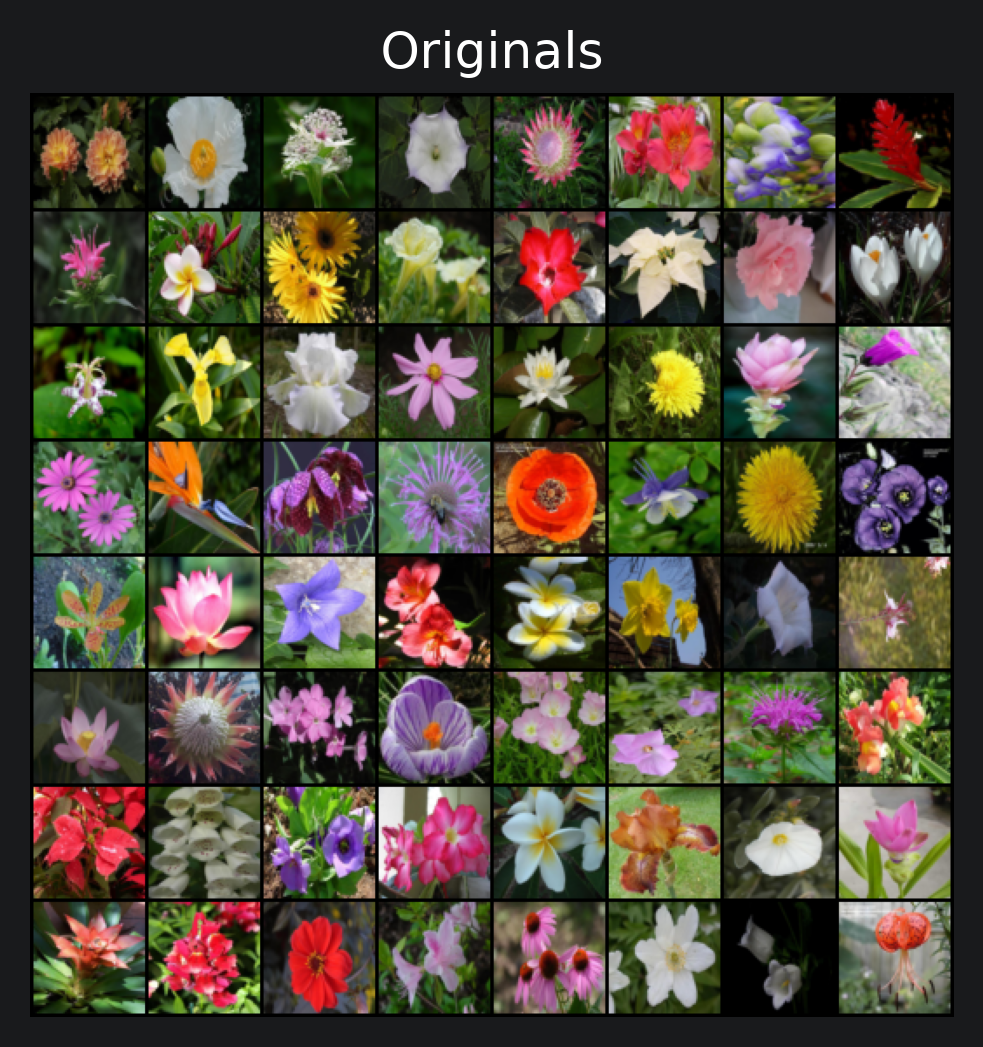

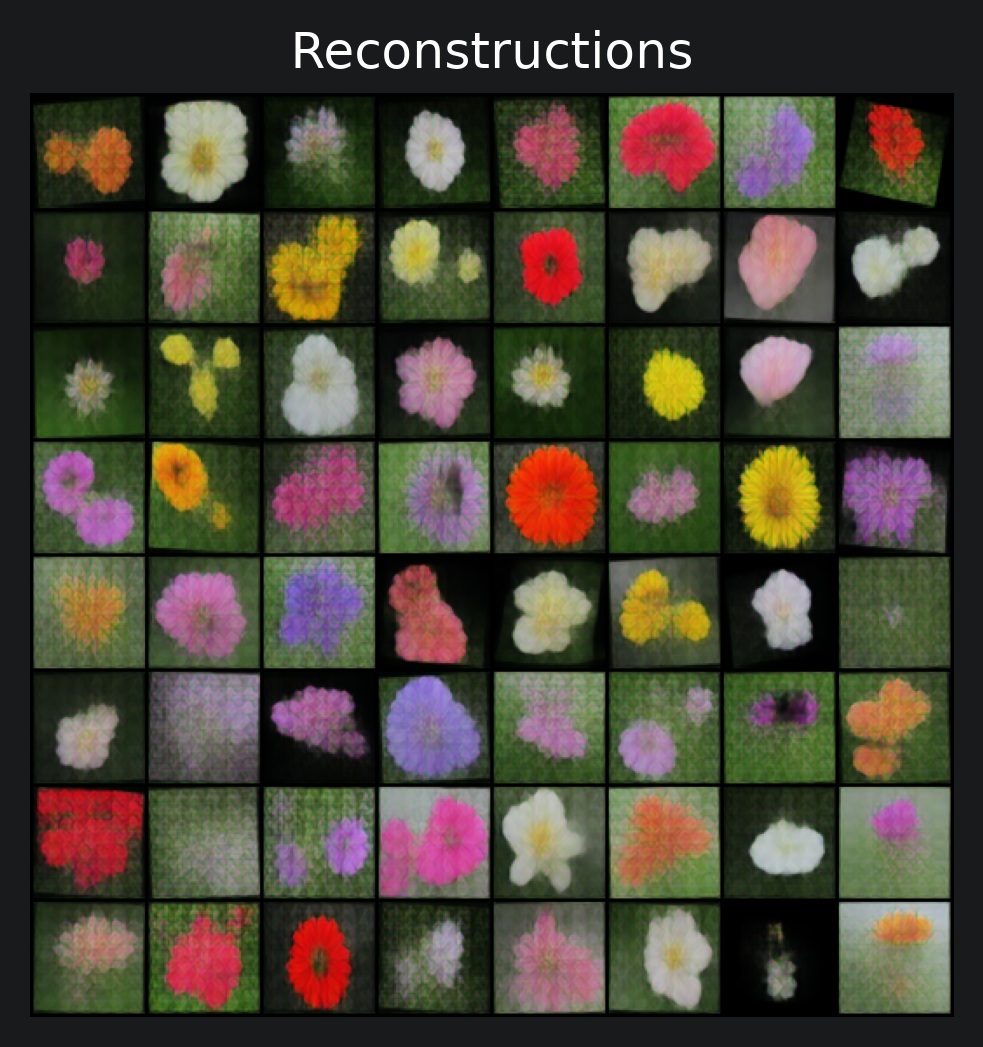

In [4]:
images, labels = next(iter(test_loader))

with torch.no_grad():
    logits, _, _ = ae(images)
    recon = torch.sigmoid(logits)

show(images, "Originals")
show(recon, "Reconstructions")


In [5]:
versions = ["v19", "v20", "v21", "v22"]
#show(images, "Originals")
for version in versions:
    ae_tmp_path = load_from_wandb("autoencoder_flowers102", tag=version)
    ae_tmp = load_ae_from_path(ae_tmp_path, device=torch.device("mps"))
    with torch.no_grad():
        logits, _, _ = ae_tmp(images)
        recon = torch.sigmoid(logits)
        show_comparison(images, recon, f"Reconstructions {version}")

Loading /Users/jakob/Studium/Thesis/master-thesis/artifacts/autoencoder_flowers102_beta1.0.pt from Weights & Biases artifact jmartini-tu-darmstadt/master-thesis/autoencoder_flowers102:v19


RuntimeError: Error(s) in loading state_dict for VariationalAutoencoder:
	Missing key(s) in state_dict: "encoder.0.res.0.block.0.weight", "encoder.0.res.0.block.0.bias", "encoder.0.res.0.block.0.running_mean", "encoder.0.res.0.block.0.running_var", "encoder.0.res.0.block.2.weight", "encoder.0.res.0.block.3.weight", "encoder.0.res.0.block.3.bias", "encoder.0.res.0.block.3.running_mean", "encoder.0.res.0.block.3.running_var", "encoder.0.res.0.block.5.weight", "encoder.1.res.0.block.0.weight", "encoder.1.res.0.block.0.bias", "encoder.1.res.0.block.0.running_mean", "encoder.1.res.0.block.0.running_var", "encoder.1.res.0.block.2.weight", "encoder.1.res.0.block.3.weight", "encoder.1.res.0.block.3.bias", "encoder.1.res.0.block.3.running_mean", "encoder.1.res.0.block.3.running_var", "encoder.1.res.0.block.5.weight", "encoder.2.res.0.block.0.weight", "encoder.2.res.0.block.0.bias", "encoder.2.res.0.block.0.running_mean", "encoder.2.res.0.block.0.running_var", "encoder.2.res.0.block.2.weight", "